In [4]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from astropy.io import fits
import matplotlib.cm as cm
import matplotlib.patches as patches
import matplotlib as mpl
from uncertainties import ufloat
from uncertainties.umath import *
from uncertainties import unumpy
from mpl_toolkits.axes_grid1 import make_axes_locatable

font = {'size'   : 6}
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']
mpl.rc('font', **font)
minorLocator = MultipleLocator(10)

AUtoCM = 1.496e13 # 1 AU = 1.496e13 cm
PCtoCM = 3.086e18 # 1 pc = 3.09e18 cm
h = 6.626e-27 #planck's constant in cm2 g s-1
k = 1.381e-16 #Boltzmann's constant in cm2 g s-2 K-1
c = 2.998e10 #light speed in cm s-1
mmw = 2.86 #mean molecular weight, (Kirk et al. 2013; Pattle et al. 2015) 
Hm = 1.674e-24 #HI mass in g

freq = 2.30538e2 #CO 2-1 freq. in GHz
bmaj = 1.36818736792e-04 * 3600 #major beam in arcsec
bmin = 9.05337437871e-05 * 3600 #minor beamin arcsec
chan_vel = 3.175 #channel velocity width in km/s
E_u = 16.59608 #upper level energy of CO 2-1 in Kelvin
Aij = 10**-6.16 #CO 2-1 A coefficient in s-1
B0 = 57635.968 #in MHz CO rotational constant https://physics.nist.gov/PhysRefData/MolSpec/Diatomic/Html/Tables/CO.html
co2H2 = 1e-4 #CO to H2 ratio, Dickman 1978
J = 2 #upper rotation level

### IAS4A outflow paras ###
dist = 300 #in pc
v0 = 4.8 #in km s-1 arcsec-1, 15.6*np.sin(18.1*np.pi/180) from pv_red_2fits1v2c1incl_6.86 
delta_vlos = 0.8 #turbulent linewidth, in km/s
Tex = 70 #in Kelvin

indi = 1 #index interval
indy = 0 #index start in y
indx = 0 #index start in x
levs0 = 5. #from chapolmap_P_241022
rms = 0.0048 #from chapolmap_P_241022

#####
d1 = fits.open("/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/python/sn3_10/data/red.i.cm.fits")
data1 = d1[0].data
data2 = data1.squeeze()
d1.close() 

red_tmp = data2[23-1,6::8,1::8]
dx = 0
dy = 1
red= red_tmp[56-13+dx:56+13+dx,56-13+dy:56+13+dy] #find dx dy with compare the index of an element in pa1 and red 
#####

d1 = fits.open('/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/python_2024/sn3_3_imbin_x5y3/imbin_x5y3/red.i23.fits')
data1 = d1[0].data
data2 = data1.squeeze()
header1 = d1[0].header
naxis1 = header1['NAXIS1']
crpix1 = header1['CRPIX1']
naxis2 = header1['NAXIS2']
crpix2 = header1['CRPIX2']
ps = header1['CDELT2']*3600 #pixel size in arcsec
X_bin,Y_bin = np.meshgrid( np.arange(0,naxis1,1)-crpix1+1,np.arange(0,naxis2,1)-crpix2+1)
#+1 because header count from 1, but python array count from 0
r_bin = np.sqrt(X_bin**2+Y_bin**2)*ps
#print(repr(header1))
d1.close() 
i1 = data2[indy::indi,indx::indi]
i1[red < levs0*rms] = np.nan

T1 = 1.222e3 * (i1*1000)/(freq**2*bmaj*bmin) #from Jy/beam to Kelvin
Qrot = k*Tex/(h*B0*1e6) + 1./3. #Eq 52 in Mangum & Shirley 2015
N1 = 8*np.pi*(freq*1e9)**2*k/(Aij*h*c**3)*Qrot/(2*J+1)*np.exp(E_u/Tex)*T1*(chan_vel*1e5)
#column density of total CO transitions in cm-2, Eq 82 in Mangum & Shirley 2015, Eq 1 in Goldsmith 1997
chan_z = chan_vel/v0*dist*AUtoCM #the line-of-sight depth of each channel in cm
n1 = N1/co2H2/chan_z #H2 number density in cm-3
rho1 = n1*mmw*Hm #density in g/cm-3

d1 = fits.open('/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/python_2024/sn3_3_imbin_x5y3/imbin_x5y3/red.pa23.fits')
data1 = d1[0].data
data1[:,r_bin > 25.3/3/2] = np.nan #mask data outside 2/3 FOV
data2 = data1.squeeze()
d1.close() 
pa1 = data2[indy::indi,indx::indi]*np.pi/180 
pa1[red < levs0*rms] = np.nan #mask data under 5 sigma

d1 = fits.open('/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/python_2024/sn3_3_imbin_x5y3/imbin_x5y3/red.paerr23.fits')
data1 = d1[0].data
data1[:,r_bin > 25.3/3/2] = np.nan 
data2 = data1.squeeze()
d1.close() 
paerr = data2[indy::indi,indx::indi]*np.pi/180
paerr[red < levs0*rms] = np.nan

pa2 = unumpy.uarray(pa1,paerr)
pa1_std = np.empty([len(pa1),len(pa1[0])]) 
pa1_std[:] = np.nan
pa1_std_u = unumpy.uarray(pa1,paerr)
pa1_std_u[:] = np.nan
        
for xx in range(1, len(pa1[0])-1):
    for yy in range(1, len(pa1)-1):
        tmp = pa2[yy-1:yy+2,xx-1:xx+2]
        tmp2 = pa1[yy-1:yy+2,xx-1:xx+2]
        tmp3 = paerr[yy-1:yy+2,xx-1:xx+2]
        weights = 1/(tmp3[~np.isnan(tmp3)]**2)
        data = tmp2[~np.isnan(tmp2)]
        if (9-np.count_nonzero(np.isnan(tmp2)) > 3):
            weighted_average = np.average(data, weights=weights)
            weighted_variance = np.average((data - weighted_average)**2, weights=weights)
            weighted_std = np.sqrt(weighted_variance)
            pa1_std[yy,xx] = weighted_std
            data = tmp[~np.isnan(tmp2)]
            pa2_mean = np.average(data, weights=weights)
            pa2_var = np.average((data - pa2_mean)**2, weights=weights)
            pa1_std_u[yy,xx] = sqrt(pa2_var)

##add 250221 to calculate distance#
#4a1: 03 29 10.529 31 13 31.05 #from Reipurth 2002
xyshift = 1.3 #find the value by fit figures
ra=np.array([3,29,10.529])
dec=np.array([31,13,31.05])
dec1_deg=dec[0]+dec[1]/60+dec[2]/3600
ra1_deg=(ra[0]+ra[1]/60+ra[2]/3600)*15
ra0_deg = header1['CRVAL1']
dec0_deg = header1['CRVAL2']
dec1_pix_offset = header1['CRPIX2']+(dec1_deg-dec0_deg)*3600/ps -xyshift+0.2
ra1_pix_offset = header1['CRPIX1']-(ra1_deg-ra0_deg)*3600*np.cos(dec0_deg*np.pi/180)/ps -xyshift

ra=np.array([3,29,10.421])
dec=np.array([31,13,32.21])
dec2_deg=dec[0]+dec[1]/60+dec[2]/3600
ra2_deg=(ra[0]+ra[1]/60+ra[2]/3600)*15
dec2_pix_offset = header1['CRPIX2']+(dec2_deg-dec0_deg)*3600/ps  -xyshift+0.2
ra2_pix_offset = header1['CRPIX1']-(ra2_deg-ra0_deg)*3600*np.cos(dec0_deg*np.pi/180)/ps -xyshift

print(np.shape(pa1))
xpix = np.shape(pa1)[1]
ypix = np.shape(pa1)[0]
print('xpix=',xpix,'ypix=',ypix)

x = np.linspace(0.,xpix-1,xpix)
y = np.linspace(0.,ypix-1,ypix)
xv, yv = np.meshgrid(x, y)

### add 251211###
pvdec_pix_offset = header1['CRPIX2']-3.42/ps -xyshift+0.2
pvra_pix_offset = header1['CRPIX1']-0.34/ps -xyshift
ra1_pix_offset2 = 10.81 #the closest point from 4A1 to major cut, computed from chatgdp
dec1_pix_offset2 = 1.55

pv_ang1 = 171.5*np.pi/180 
pv_ang2 = 81.5*np.pi/180 
c1_para = 1.70*ps
c2_para = 17*ps
x1_parabolic = np.linspace(-3.5, 3.5, 100)
x2_parabolic = np.linspace(-1.5, 1.5, 100)
y1_parabolic = c1_para * x1_parabolic**2
y2_parabolic = c2_para * x2_parabolic**2

theta = pv_ang1 - np.pi
cos_t = np.cos(theta)
sin_t = np.sin(theta)
cos_t2 = np.cos(-theta)
sin_t2 = np.sin(-theta)
xv_offset = xv - ra1_pix_offset2
yv_offset = yv - dec1_pix_offset2

x1_parabolic_rot = ra1_pix_offset2 + x1_parabolic*cos_t - y1_parabolic*sin_t
y1_parabolic_rot = dec1_pix_offset2 + x1_parabolic*sin_t + y1_parabolic*cos_t
x2_parabolic_rot = ra1_pix_offset2 + x2_parabolic*cos_t - y2_parabolic*sin_t
y2_parabolic_rot = dec1_pix_offset2 + x2_parabolic*sin_t + y2_parabolic*cos_t
xv_offset_rot = xv_offset*cos_t2 - yv_offset*sin_t2 #the r from (ra1_pix_offset2, dec1_pix_offset2) in cylindrical coordinate
yv_offset_rot = xv_offset*sin_t2 + yv_offset*cos_t2 #the z from (ra1_pix_offset2, dec1_pix_offset2) in cylindrical coordinate

r_rot_max = np.sqrt(yv_offset_rot/c2_para)
vg = 21.5 #velocity gradient 21.5 au/(km/s)
v_rot0 = np.sqrt(1.3/c2_para*ps)*300/vg #rotational velocity at z = 1.3" (400au) of the C_high = 17 arcsec-1 outflow shell
print(v_rot0)
v_rot_pos = v_rot0*yv_offset_rot/(1.3/ps)*np.sqrt(r_rot_max**2-xv_offset_rot**2)/r_rot_max #assume rot velocity is proporsional to yv_offset_rot
v_rot_pos[np.abs(xv_offset_rot) > r_rot_max] = 0

(26, 26)
xpix= 26 ypix= 26
3.8586022238718987


/var/folders/sx/1b55yzdj67g8dg8fyg5xygx00000gn/T/ipykernel_40531/3190239624.py:186: RuntimeWarning: invalid value encountered in sqrt
  r_rot_max = np.sqrt(yv_offset_rot/c2_para)
/var/folders/sx/1b55yzdj67g8dg8fyg5xygx00000gn/T/ipykernel_40531/3190239624.py:190: RuntimeWarning: invalid value encountered in sqrt
  v_rot_pos = v_rot0*yv_offset_rot/(1.3/ps)*np.sqrt(r_rot_max**2-xv_offset_rot**2)/r_rot_max #assume rot velocity is proporsional to yv_offset_rot


In [5]:
bf = 0.5*np.sqrt(4*np.pi*rho1)/pa1_std*(delta_vlos*1e5)*1e3 #B field strength, in mG
bf[np.isnan(pa1)] = np.nan
bf_u = 0.5*np.sqrt(4*np.pi*rho1)/pa1_std_u*(delta_vlos*1e5)*1e3 #B field strength uncertainty, in mG
bf_u[np.isnan(pa1)] = np.nan

### add 251211 ###
U0 = v_rot_pos #4 #1 km/s
mbf = bf*np.abs(1-pa1_std*U0/delta_vlos)
mbf_u = 0.5*np.sqrt(4*np.pi*rho1)/pa1_std_u*(delta_vlos*1e5)*1e3*np.abs(1-pa1_std*U0/delta_vlos) #B field strength uncertainty, in mG
mbf_u[np.isnan(pa1)] = np.nan

bf = mbf
bf_u = mbf_u
va = bf*1e-3/np.sqrt(4*np.pi*rho1)/1e5 #alfven velocity in km/s
######

Px=np.sin(pa1)
Py=np.cos(pa1)
Bx=np.sin(pa1)*bf*-1
By=np.cos(pa1)*bf*-1
#-1 because the magnetic field direction is position angle + 180 degrees
#the Bpos direction in the foreground is opposite to the Bpos direction in the background

Bx_u = unumpy.uarray(pa1,paerr)
Bx_u[:] = np.nan
By_u = unumpy.uarray(pa1,paerr)
By_u[:] = np.nan

for xx in range(1, len(pa1[0])-1):
    for yy in range(1, len(pa1)-1):
        Bx_u[yy,xx]=sin(pa2[yy,xx])*bf_u[yy,xx]
        By_u[yy,xx]=cos(pa2[yy,xx])*bf_u[yy,xx]

pixel = 0.4 #pixel size in arcsec
dBydy_2, dBydx_2 = np.gradient(By/(pixel*dist*AUtoCM)) #in unit of mG cm-1
dBxdy_2, dBxdx_2 = np.gradient(Bx/(pixel*dist*AUtoCM))
dBydy = dBydy_2 
dBxdy = dBxdy_2 
dBydx = dBydx_2*-1
dBxdx = dBxdx_2*-1
#-1 because the ra direction is opposite to the pixel direction

By_u_x0 = By_u[:,:-2] 
By_u_x2 = By_u[:,2:]
By_x0 = By[:,:-2] 
By_x2 = By[:,2:] 
dBydx_tmp = (By_x2-By_x0)/(2*pixel*dist*AUtoCM)*-1
dBydx_u = (By_u_x2-By_u_x0)/(2*pixel*dist*AUtoCM)*-1
#print(dBydx_u[~np.isnan(dBydx_tmp)])
#print(dBydx_2[~np.isnan(dBydx_2)])

By_u_y0 = By_u[:-2,:] 
By_u_y2 = By_u[2:,:]
By_y0 = By[:-2,:] 
By_y2 = By[2:,:] 
dBydy_tmp = (By_y2-By_y0)/(2*pixel*dist*AUtoCM)
dBydy_u = (By_u_y2-By_u_y0)/(2*pixel*dist*AUtoCM)
#print(dBydy_u[~np.isnan(dBydy_tmp)])
#print(dBydy_2[~np.isnan(dBydy_2)])

Bx_u_x0 = Bx_u[:,:-2] 
Bx_u_x2 = Bx_u[:,2:]
Bx_x0 = Bx[:,:-2] 
Bx_x2 = Bx[:,2:] 
dBxdx_tmp = (Bx_x2-Bx_x0)/(2*pixel*dist*AUtoCM)*-1
dBxdx_u = (Bx_u_x2-Bx_u_x0)/(2*pixel*dist*AUtoCM)*-1
#print(dBxdx_u[~np.isnan(dBxdx_tmp)])
#print(dBxdx_2[~np.isnan(dBxdx_2)])

Bx_u_y0 = Bx_u[:-2,:] 
Bx_u_y2 = Bx_u[2:,:]
Bx_y0 = Bx[:-2,:] 
Bx_y2 = Bx[2:,:] 
dBxdy_tmp = (Bx_y2-Bx_y0)/(2*pixel*dist*AUtoCM)
dBxdy_u = (Bx_u_y2-Bx_u_y0)/(2*pixel*dist*AUtoCM)
#print(dBxdy_u[~np.isnan(dBxdy_tmp)])
#print(dBxdy_2[~np.isnan(dBxdy_2)])

dBxdx[np.isnan(pa1)] = 'nan'
dBxdy[np.isnan(pa1)] = 'nan'
dBydx[np.isnan(pa1)] = 'nan'
dBydy[np.isnan(pa1)] = 'nan'

dBydx_dBxdy = (dBydx - dBxdy).flatten()
dBydx_dBxdy_u = (dBydx_u[1:-1,:] - dBxdy_u[:,1:-1]).flatten()
dBydx_dBxdy_tmp = (dBydx_tmp[1:-1,:] - dBxdy_tmp[:,1:-1]).flatten()
dBydx_dBxdy_velues = dBydx_dBxdy[~np.isnan(dBydx_dBxdy)]
dBydx_dBxdy_u_velues = dBydx_dBxdy_u[~np.isnan(dBydx_dBxdy_tmp)]

dBerr = np.empty(len(dBydx_dBxdy_velues)) 
for xx in range(0, len(dBerr)):
    dBerr[xx] = dBydx_dBxdy_u_velues[xx].std_dev

print(dBydx_dBxdy_velues)
print(dBydx_dBxdy_u_velues)
print(dBerr)


[-3.80250970e-19 -2.24878571e-16 -8.68580626e-16]
[3.802738593541138e-19+/-2.588787257476542e-16
 2.2487850719596723e-16+/-5.816152090414558e-16
 8.68580609224984e-16+/-4.037590302388725e-16]
[2.58878726e-16 5.81615209e-16 4.03759030e-16]


/var/folders/sx/1b55yzdj67g8dg8fyg5xygx00000gn/T/ipykernel_40531/251938225.py:151: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  plt.errorbar(i2[~np.isnan(dBydx_dBxdy)],dBydx_dBxdy_velues,yerr=dBerr, fmt='ro',c='Gray', alpha=plt_alpha, markersize=marker_size)


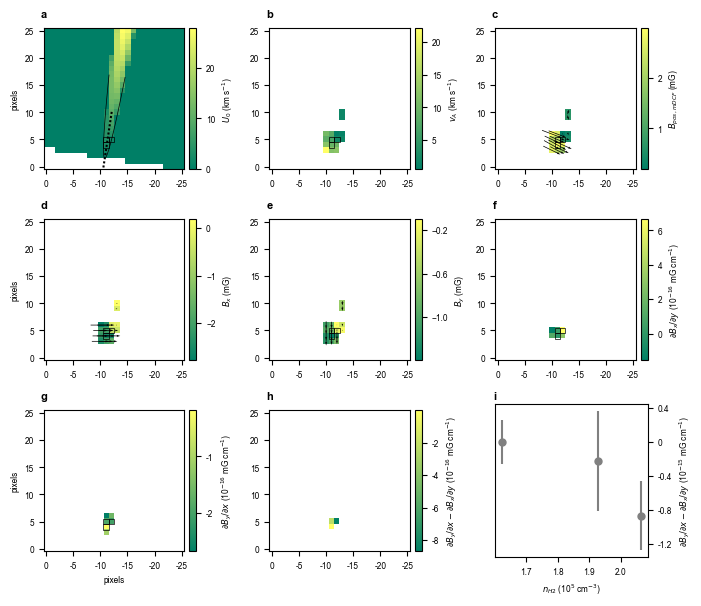

In [6]:

fig = plt.figure(figsize=(7,7), layout='tight')
fig.subplots_adjust(0.06, 0.015, 0.93, 0.98, 0.43,  -0.35)
extent0=[-0.5, xpix-0.5, -0.5, ypix-0.5]
cmp0=cm.summer
sc = 20 #scale for quiver
wd = 0.005 #width for quiver

#####
new_tick_locations = np.array([0,5,10,15,20,25])
panellabelx = 0
panellabely = 1.1

def highlight_cell(x,y, ax=None, **kwargs):
    rect = plt.Rectangle((x-.5, y-.5), 1,1, fill=False, **kwargs)
    ax = ax or plt.gca()
    ax.add_patch(rect)
    return rect

xv_1 = xv[~np.isnan(dBydx - dBxdy)]
yv_1 = yv[~np.isnan(dBydx - dBxdy)]
######

ax1 = plt.subplot(3,3,1)
plt.ylabel('pixels')
ax1.set(aspect=1)
ax1.set_xticks(new_tick_locations)
ax1.set_xticklabels([0,-5,-10,-15,-20,-25])
for xx2 in range(0, len(xv_1)):
    highlight_cell(xv_1[xx2],yv_1[xx2], color="k", linewidth=0.5)

ax1.plot([pvra_pix_offset-np.sin(pv_ang1)*3.5/ps,pvra_pix_offset+np.sin(pv_ang1)*2.5/ps], \
         [pvdec_pix_offset+np.cos(pv_ang1)*3.5/ps,pvdec_pix_offset-np.cos(pv_ang1)*2.5/ps],'k', linestyle=(0,(1,1)), zorder=50)
ax1.plot(x2_parabolic_rot, y2_parabolic_rot,color='k', linewidth=0.5)

cs = plt.imshow(v_rot_pos, interpolation='none', cmap=cmp0, extent=extent0, origin='lower')
divider = make_axes_locatable(ax1)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(cs,cax=cax,ticks=np.arange(0,21,10))
cbar.set_label(r'$U_{0}$ (km s$^{-1}$)')
ax1.text(panellabelx,panellabely, r'a',horizontalalignment='center',verticalalignment='center',transform=ax1.transAxes, fontsize=8, weight='bold')

ax1 = plt.subplot(3,3,2)
ax1.set(aspect=1)
ax1.set_xticks(new_tick_locations)
ax1.set_xticklabels([0,-5,-10,-15,-20,-25])
for xx2 in range(0, len(xv_1)):
    highlight_cell(xv_1[xx2],yv_1[xx2], color="k", linewidth=0.5)

cs = plt.imshow(va, interpolation='nearest', cmap=cmp0, extent=extent0, origin='lower')
divider = make_axes_locatable(ax1)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(cs,cax=cax,ticks=np.arange(5,21,5))
cbar.set_label(r'$v_{A}$ (km s$^{-1}$)')
ax1.text(panellabelx,panellabely, r'b',horizontalalignment='center',verticalalignment='center',transform=ax1.transAxes, fontsize=8, weight='bold')

ax1 = plt.subplot(3,3,3)
ax1.set(aspect=1)
ax1.quiver(xv, yv, -1*Bx, By, color='k', \
           scale=sc, width=wd, pivot='mid',edgecolor='none')
cs = plt.imshow(bf, interpolation='nearest', cmap=cmp0, extent=extent0, origin='lower')
#-1 because the ra direction is opposite to the pixel direction
ax1.set_xticks(new_tick_locations)
ax1.set_xticklabels([0,-5,-10,-15,-20,-25])
for xx2 in range(0, len(xv_1)):
    highlight_cell(xv_1[xx2],yv_1[xx2], color="k", linewidth=0.5)

divider = make_axes_locatable(ax1)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(cs,cax=cax,ticks=np.arange(1,3.1,1))
cbar.set_label(r'$B_{pos,mDCF}$ (mG)')
ax1.text(panellabelx,panellabely, r'c',horizontalalignment='center',verticalalignment='center',transform=ax1.transAxes, fontsize=8, weight='bold')

ax4 = plt.subplot(3,3,4)
plt.ylabel('pixels')
ax4.quiver(xv, yv, -1*Bx, 0, color='k', \
           scale=sc, width=wd, pivot='mid',edgecolor='none')
cs = ax4.imshow(Bx, interpolation='nearest', cmap=cmp0, extent=extent0, origin='lower')
ax4.set_xticks(new_tick_locations)
ax4.set_xticklabels([0,-5,-10,-15,-20,-25])
for xx2 in range(0, len(xv_1)):
    highlight_cell(xv_1[xx2],yv_1[xx2], color="k", linewidth=0.5)

divider = make_axes_locatable(ax4)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(cs,cax=cax,ticks=np.arange(-2,3.1,1))
cbar.set_label(r'$B_x$ (mG)')
ax4.text(panellabelx,panellabely, r'd',horizontalalignment='center',verticalalignment='center',transform=ax4.transAxes, fontsize=8, weight='bold')

ax7 = plt.subplot(3,3,5)
ax7.quiver(xv, yv, 0, By, color='k', \
           scale=sc, width=wd, pivot='mid',edgecolor='none')
cs = plt.imshow(By, interpolation='nearest', cmap=cmp0, extent=extent0, origin='lower')
ax7.set_xticks(new_tick_locations)
ax7.set_xticklabels([0,-5,-10,-15,-20,-25])
for xx2 in range(0, len(xv_1)):
    highlight_cell(xv_1[xx2],yv_1[xx2], color="k", linewidth=0.5)

divider = make_axes_locatable(ax7)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(cs,cax=cax,ticks=np.arange(-1.0,0,0.4))
cbar.set_label(r'$B_y$ (mG)')
ax7.text(panellabelx,panellabely, r'e',horizontalalignment='center',verticalalignment='center',transform=ax7.transAxes, fontsize=8, weight='bold')

ax6 = plt.subplot(3,3,6)
cs = ax6.imshow(dBxdy, interpolation='nearest', cmap=cmp0, extent=extent0, origin='lower')
ax6.set_xticks(new_tick_locations)
ax6.set_xticklabels([0,-5,-10,-15,-20,-25])
for xx2 in range(0, len(xv_1)):
    highlight_cell(xv_1[xx2],yv_1[xx2], color="k", linewidth=0.5)

divider = make_axes_locatable(ax6)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(cs,cax=cax,ticks=np.arange(0,6.1,2)*1e-16)
cbar.set_label(r'$\partial B_x/\partial y$ (10$^{-16}$ mG cm$^{-1}$)')
cbar.ax.set_yticklabels(['0','2','4','6'])
ax6.text(panellabelx,panellabely, r'f',horizontalalignment='center',verticalalignment='center',transform=ax6.transAxes, fontsize=8, weight='bold')

ax8 = plt.subplot(3,3,7)
plt.xlabel('pixels')
cs = plt.imshow(dBydx, interpolation='nearest', cmap=cmp0, extent=extent0, origin='lower')
#-1 because the ra direction is opposite to the pixel direction
plt.xlabel('pixels')
plt.ylabel('pixels')
ax8.set_xticks(new_tick_locations)
ax8.set_xticklabels([0,-5,-10,-15,-20,-25])
for xx2 in range(0, len(xv_1)):
    highlight_cell(xv_1[xx2],yv_1[xx2], color="k", linewidth=0.5)

divider = make_axes_locatable(ax8)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(cs,cax=cax,ticks=np.arange(-2,-0.9,1)*1e-16)
cbar.set_label(r'$\partial B_y/\partial x$ (10$^{-16}$ mG cm$^{-1}$)')
cbar.ax.set_yticklabels(['-2','-1'])
ax8.text(panellabelx,panellabely, r'g',horizontalalignment='center',verticalalignment='center',transform=ax8.transAxes, fontsize=8, weight='bold')

ax3 = plt.subplot(3,3,8)
cs = plt.imshow(dBydx - dBxdy, interpolation='nearest', cmap=cmp0, extent=extent0, origin='lower')
ax3.set_xticks(new_tick_locations)
ax3.set_xticklabels([0,-5,-10,-15,-20,-25])
divider = make_axes_locatable(ax3)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(cs,cax=cax,ticks=np.arange(-8,-1,2)*1e-16)
cbar.set_label(r'$\partial B_y/\partial x - \partial B_x/\partial y$ (10$^{-16}$ mG cm$^{-1}$)')
cbar.ax.set_yticklabels(['-8','-6','-4','-2'])
ax3.text(panellabelx,panellabely, r'h',horizontalalignment='center',verticalalignment='center',transform=ax3.transAxes, fontsize=8, weight='bold')

marker_size=5
plt_alpha = 1
ax2 = plt.subplot(3,3,9)
i2 = n1.flatten()
plt.errorbar(i2[~np.isnan(dBydx_dBxdy)],dBydx_dBxdy_velues,yerr=dBerr, fmt='ro',c='Gray', alpha=plt_alpha, markersize=marker_size)
plt.xlabel(r'$n_{H2}$ (10$^5$ cm$^{-3}$)')
plt.ylabel(r'$\partial B_y/\partial x - \partial B_x/\partial y$ (10$^{-15}$ mG cm$^{-1}$)')
ax2.text(panellabelx,panellabely-0.05, r'i',horizontalalignment='center',verticalalignment='center',transform=ax2.transAxes, fontsize=8, weight='bold')
ax2.set_aspect(1.0/ax2.get_data_ratio(), adjustable='box')
ax2.set_xticks(ticks=np.arange(1.7,2.01,0.1)*1e5)
ax2.set_xticklabels(['1.7','1.8','1.9','2.0'])
ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()
ax2.set_yticks(ticks=np.arange(-1.2,0.5,0.4)*1e-15)
ax2.set_yticklabels(['-1.2','-0.8','-0.4','0','0.4'])

#plt.show()
plt.savefig('maxwell23_fullmap_B_uncertainty_251210_paerrweight_positiveJ_mDCF_sds.pdf', bbox_inches='tight', pad_inches=0.01)

np.savetxt('output/n23.txt',i2[~np.isnan(dBydx_dBxdy)])
np.savetxt('output/dB23.txt',dBydx_dBxdy[~np.isnan(dBydx_dBxdy)])
np.savetxt('output/dBerr23.txt',dBerr)

np.save('bf23',bf)
np.save('dBydx-dBxdy23',dBydx - dBxdy)


In [ ]:
dis_pix = np.sqrt((xv_1 -ra1_pix_offset)**2+(yv_1-dec1_pix_offset)**2) #distance to 4A1 in pixels
dis_au = dis_pix*ps*dist
Bferr = np.empty(len(dBydx_dBxdy_velues)) 
bf_u_tmp = bf_u.flatten()[~np.isnan(dBydx_dBxdy)]
for xx in range(0, len(Bferr)):
    Bferr[xx] = bf_u_tmp[xx].std_dev

np.savetxt('output/dist23.txt',dis_au)
np.savetxt('output/Bf23.txt',bf.flatten()[~np.isnan(dBydx_dBxdy)])
np.savetxt('output/Bferr23.txt',Bferr)

In [4]:
width_in, height_in = fig.get_size_inches()

width_mm = width_in * 25.4
height_mm = height_in * 25.4

print(width_mm, height_mm)
print(mpl.rcParams['font.family'])
print(mpl.rcParams['font.sans-serif'])


177.79999999999998 177.79999999999998
['sans-serif']
['Arial']


In [7]:
import pyperclip

tmpx2 = v_rot_pos[~np.isnan(v_rot_pos)]
tmpx3 = tmpx2.flatten()
output_text = "\n".join(map(str, tmpx3))
#print(output_text, sep='\n')
pyperclip.copy(output_text)

In [12]:
rows, cols = np.where(~np.isnan(v_rot_pos))
#print(rows)
#print(cols)
tmpx2 = rows
tmpx3 = tmpx2.flatten()
output_text = "\n".join(map(str, tmpx3))
#print(output_text, sep='\n')
pyperclip.copy(output_text)

In [13]:
tmpx2 = cols*-1
tmpx3 = tmpx2.flatten()
output_text = "\n".join(map(str, tmpx3))
#print(output_text, sep='\n')
pyperclip.copy(output_text)

In [35]:

tmpx2 = va[~np.isnan(va)]
tmpx3 = tmpx2.flatten()
output_text = "\n".join(map(str, tmpx3))
#print(output_text, sep='\n')
pyperclip.copy(output_text)

In [15]:
rows, cols = np.where(~np.isnan(va))
#print(rows)
#print(cols)
tmpx2 = rows
tmpx3 = tmpx2.flatten()
output_text = "\n".join(map(str, tmpx3))
#print(output_text, sep='\n')
pyperclip.copy(output_text)

In [16]:
tmpx2 = cols*-1
tmpx3 = tmpx2.flatten()
output_text = "\n".join(map(str, tmpx3))
#print(output_text, sep='\n')
pyperclip.copy(output_text)

In [17]:

tmpx2 = bf[~np.isnan(bf)]
tmpx3 = tmpx2.flatten()
output_text = "\n".join(map(str, tmpx3))
#print(output_text, sep='\n')
pyperclip.copy(output_text)

In [18]:
rows, cols = np.where(~np.isnan(bf))
#print(rows)
#print(cols)
tmpx2 = rows
tmpx3 = tmpx2.flatten()
output_text = "\n".join(map(str, tmpx3))
#print(output_text, sep='\n')
pyperclip.copy(output_text)

In [19]:
tmpx2 = cols*-1
tmpx3 = tmpx2.flatten()
output_text = "\n".join(map(str, tmpx3))
#print(output_text, sep='\n')
pyperclip.copy(output_text)

In [20]:
tmpx1 = pa1[~np.isnan(bf)]*180/np.pi-180
tmpx2 = np.where(tmpx1 < -180, tmpx1+360, tmpx1)
tmpx3 = tmpx2.flatten()
output_text = "\n".join(map(str, tmpx3))
#print(output_text, sep='\n')
pyperclip.copy(output_text)

In [21]:

tmpx2 = Bx[~np.isnan(Bx)]
tmpx3 = tmpx2.flatten()
output_text = "\n".join(map(str, tmpx3))
#print(output_text, sep='\n')
pyperclip.copy(output_text)

In [22]:
tmpx2 = By[~np.isnan(By)]
tmpx3 = tmpx2.flatten()
output_text = "\n".join(map(str, tmpx3))
#print(output_text, sep='\n')
pyperclip.copy(output_text)

In [23]:
tmpx2 = dBxdy[~np.isnan(dBxdy)]
tmpx3 = tmpx2.flatten()
output_text = "\n".join(map(str, tmpx3))
#print(output_text, sep='\n')
pyperclip.copy(output_text)

In [24]:
rows, cols = np.where(~np.isnan(dBxdy))
#print(rows)
#print(cols)
tmpx2 = rows
tmpx3 = tmpx2.flatten()
output_text = "\n".join(map(str, tmpx3))
#print(output_text, sep='\n')
pyperclip.copy(output_text)

In [25]:
tmpx2 = cols*-1
tmpx3 = tmpx2.flatten()
output_text = "\n".join(map(str, tmpx3))
#print(output_text, sep='\n')
pyperclip.copy(output_text)

In [26]:
tmpx2 = dBydx[~np.isnan(dBydx)]
tmpx3 = tmpx2.flatten()
output_text = "\n".join(map(str, tmpx3))
#print(output_text, sep='\n')
pyperclip.copy(output_text)

In [27]:
rows, cols = np.where(~np.isnan(dBydx))
#print(rows)
#print(cols)
tmpx2 = rows
tmpx3 = tmpx2.flatten()
output_text = "\n".join(map(str, tmpx3))
#print(output_text, sep='\n')
pyperclip.copy(output_text)

In [28]:
tmpx2 = cols*-1
tmpx3 = tmpx2.flatten()
output_text = "\n".join(map(str, tmpx3))
#print(output_text, sep='\n')
pyperclip.copy(output_text)

In [29]:
tmpx1 = dBydx - dBxdy
tmpx2 = tmpx1[~np.isnan(tmpx1)]
tmpx3 = tmpx2.flatten()
output_text = "\n".join(map(str, tmpx3))
#print(output_text, sep='\n')
pyperclip.copy(output_text)

In [30]:
rows, cols = np.where(~np.isnan(tmpx1))
#print(rows)
#print(cols)
tmpx2 = rows
tmpx3 = tmpx2.flatten()
output_text = "\n".join(map(str, tmpx3))
#print(output_text, sep='\n')
pyperclip.copy(output_text)

In [31]:
tmpx2 = cols*-1
tmpx3 = tmpx2.flatten()
output_text = "\n".join(map(str, tmpx3))
#print(output_text, sep='\n')
pyperclip.copy(output_text)

In [32]:
#plt.errorbar(i2[~np.isnan(dBydx_dBxdy)],dBydx_dBxdy_velues,yerr=dBerr, fmt='ro',c='Gray', alpha=plt_alpha, markersize=marker_size)
tmpx2 = i2[~np.isnan(dBydx_dBxdy)]/1e5
tmpx3 = tmpx2.flatten()
output_text = "\n".join(map(str, tmpx3))
#print(output_text, sep='\n')
pyperclip.copy(output_text)

In [33]:
tmpx2 = dBydx_dBxdy_velues
tmpx3 = tmpx2.flatten()
output_text = "\n".join(map(str, tmpx3))
#print(output_text, sep='\n')
pyperclip.copy(output_text)

In [34]:
tmpx2 = dBerr
tmpx3 = tmpx2.flatten()
output_text = "\n".join(map(str, tmpx3))
#print(output_text, sep='\n')
pyperclip.copy(output_text)